In [1]:
import numpy as np
import pandas as pd
import pickle as pkl
from src.rset_opt import *
from src.run_app import *
from src.prepare_gam import *
from src.utils import *

In [2]:
filepath = "diabetes_0.001_0.5_0.01.p"

model = RSetOPT(filepath)
model.finetune_ellipsoid()
model.get_precision()
H_opt = model.get_normalized_H()
w_opt = model.w_orig

# store optimized hessian and w to the file
model.update_file(H_opt, w_opt)

----------- before optimization -----------
volume proportional to  tensor(1.9860e+29, dtype=torch.float64, grad_fn=<MulBackward0>)
0 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
1 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
2 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
3 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
4 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
5 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
6 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
7 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
8 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
9 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
10 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
11 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
12 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
13 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
14 tensor(nan, dtype=torch.float64, gr

/Users/christopherli/Documents/Junior/GAMsRashomonSet/src/rset_opt.py:112: RuntimeWarning: invalid value encountered in scalar power
  dw_samples = ( self.H_half.inverse() @ x_.t() * ((ub*2)**0.5) ).t() # transformation to a ellipsoid


34 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
35 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
36 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
37 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
38 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
39 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
40 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
41 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
42 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
43 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
44 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
45 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
46 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
47 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
48 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
49 tensor(nan, dtype=torch.float64, grad_fn=<AddBackward0>)
50 tensor(nan, dtype=torch.float64, grad

header dimension 1255
lamb0:0.001, lamb2:0.5, acc:0.7786458333333334, auc:0.8580223880597014, supp_size:40
pair before removing {'Pregnancies': [6.0], 'Glucose': [99.0, 100.0, 101.0, 103.0, 106.0, 111.0, 114.0, 123.0, 124.0, 127.0, 128.0, 129.0, 143.0, 144.0, 154.0, 155.0, 157.0, 159.0, 165.0, 166.0], 'BMI': [26.2, 26.3, 26.4, 26.9, 27.3, 27.8, 28.8, 29.8, 29.9, 40.8], 'DiabetesPedigreeFunction': [0.501, 0.718], 'Age': [24.0, 26.0, 27.0, 28.0, 29.0, 30.0]}
k, v Pregnancies [6.0, 17]
k, v Glucose [99.0, 100.0, 101.0, 103.0, 106.0, 111.0, 114.0, 123.0, 124.0, 127.0, 128.0, 129.0, 143.0, 144.0, 154.0, 155.0, 157.0, 159.0, 165.0, 166.0, 199]
k, v BMI [26.2, 26.3, 26.4, 26.9, 27.3, 27.8, 28.8, 29.8, 29.9, 40.8, 67.1]
k, v DiabetesPedigreeFunction [0.501, 0.718, 2.42]
k, v Age [24.0, 26.0, 27.0, 28.0, 29.0, 30.0, 81]
pair after removing {'Pregnancies': [6.0, 17], 'Glucose': [99.0, 100.0, 101.0, 103.0, 106.0, 111.0, 114.0, 123.0, 124.0, 127.0, 128.0, 129.0, 143.0, 144.0, 154.0, 155.0, 157.0, 

<Figure size 550x400 with 0 Axes>

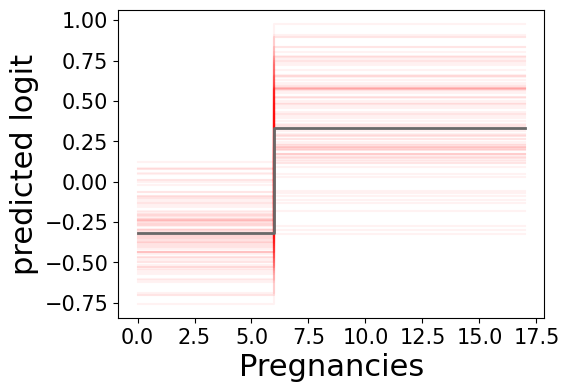

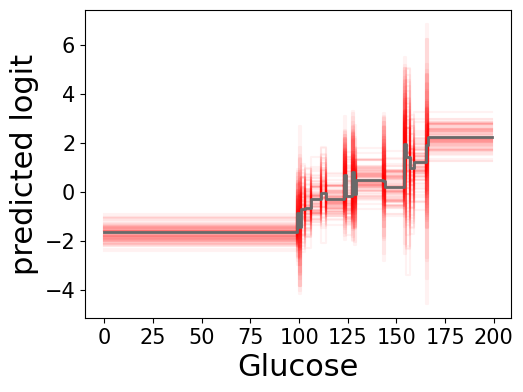

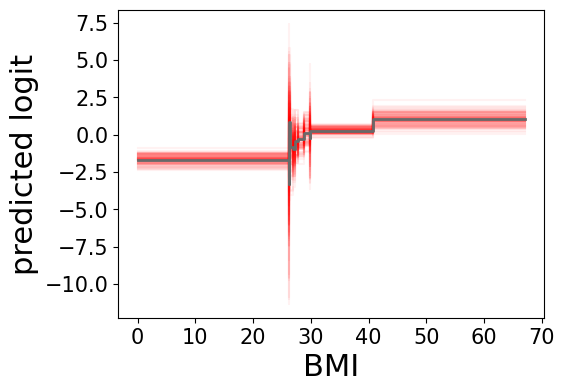

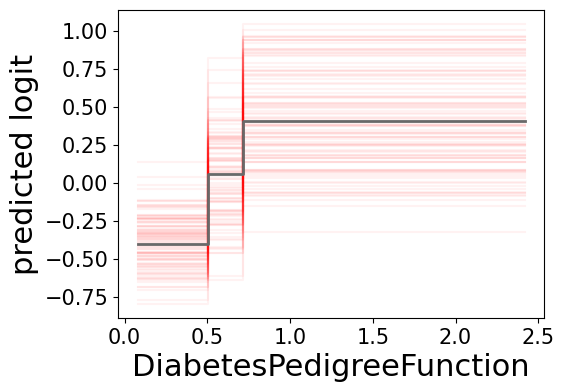

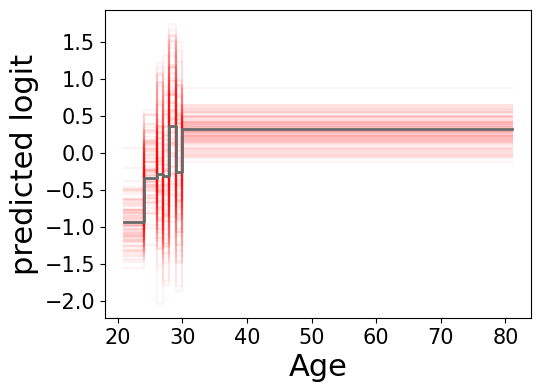

In [23]:
dname = "diabetes"
l0 = 0.001
l2 = 0.5
m = 0.01
betas_fastSparse = prepare_sparse_gam(dname, lamb0=l0, lamb2=l2, multiplier=1.01)
filepath = "{}_{}_{}_{}.p".format(dname, l0, l2, m)

w_samples = get_models_from_rset(filepath, n_samples=100, plot_shape=True, sample_from_surface=False)

In [22]:
w_samples[0]

array([ 0.08842268, -0.39397527,  0.58553819, -1.82384165, -1.42579004,
       -3.34908893,  1.15181675, -1.03045572, -0.27662966, -0.60512517,
        0.00652565,  0.59766937, -0.45067158,  0.14081942, -1.4604445 ,
        0.89069834,  1.10945552, -0.31398957,  4.50882112,  0.85962739,
        1.37010888,  0.9714997 ,  4.0758367 ,  2.54857535, -1.4919269 ,
       -5.99146242, -2.73026829, -1.02012643, -1.80501363, -1.90908162,
       -0.38099736, -0.27804914,  1.87005384,  0.15842244,  0.75610653,
       -0.25656344, -0.26069571,  1.00213127, -1.39165617, -0.45879076,
       -0.88718837, -0.51826582,  1.41738432, -0.73186028, -0.07520181])

In [25]:
w_samples.shape

(100, 45)

In [ ]:
from gam_rs_utils.utils import *

for diversity_fnc in [inverse_IoU, euclidean_distance, inverse_cosine_similarity]:
    col_name = f"diversity_{diversity_fnc.__name__}"
    print(average_pairwise_diversity(w_samples, diversity_fnc, 50))

X = pkl.load(open(betas_fastSparse, 'rb'))['X']
# print(average_pairwise_diversity(w_samples, inverse_correlation, 50, X))

0.0
10.210001551573392
0.5709619709606196
